In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("DS_Day01_26_Manufacturing_Dataset.csv")

df.head()

,Date,Machine_ID,Machine_Output,Downtime,Shift,Operator,Temperature,Maintenance_Status,Production_Volume
0,2025-01-01,M01,73.51,24.09,Morning,OP09,31.81,Overdue,53.17
1,2025-01-01,M05,81.21,16.56,Evening,OP13,32.56,Due,77.41
2,2025-01-01,M08,79.73,13.98,Morning,OP13,35.75,Due,72.54
3,2025-01-01,M08,87.41,5.79,Morning,OP07,31.80,Good,85.70
4,2025-01-01,M10,82.78,15.43,Night,OP15,25.88,Due,74.50


In [ ]:
df.shape

(1200, 9)

In [ ]:
df.columns

Index(['Date', 'Machine_ID', 'Machine_Output', 'Downtime', 'Shift', 'Operator',
       'Temperature', 'Maintenance_Status', 'Production_Volume'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                1200 non-null   object 
 1   Machine_ID          1200 non-null   object 
 2   Machine_Output      1200 non-null   float64
 3   Downtime            1200 non-null   float64
 4   Shift               1200 non-null   object 
 5   Operator            1200 non-null   object 
 6   Temperature         1200 non-null   float64
 7   Maintenance_Status  1200 non-null   object 
 8   Production_Volume   1200 non-null   float64
dtypes: float64(4), object(5)
memory usage: 84.5+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Machine_ID,0
Machine_Output,0
Downtime,0
Shift,0
Operator,0
Temperature,0
Maintenance_Status,0
Production_Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Machine_Output,Downtime,Temperature,Production_Volume
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,92.339283,10.915258,28.904683,86.216225
std,16.152296,6.436754,3.936052,19.875548
min,38.010000,0.270000,20.000000,13.850000
25%,82.322500,5.890000,26.267500,74.112500
50%,94.160000,9.990000,28.830000,88.605000
75%,104.300000,14.692500,31.580000,101.047500
max,129.100000,35.000000,40.000000,133.160000


In [ ]:
print("Machines:", df["Machine_ID"].unique())
print("Shifts:", df["Shift"].unique())
print("Operators:", df["Operator"].nunique())
print("Maintenance:", df["Maintenance_Status"].unique())

Machines: ['M01' 'M05' 'M08' 'M10' 'M03' 'M04' 'M06' 'M07' 'M09' 'M02']
Shifts: ['Morning' 'Evening' 'Night']
Operators: 15
Maintenance: ['Overdue' 'Due' 'Good']


Data Cleaning & **Validation**

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df.dtypes

,0
Date,datetime64[ns]
Machine_ID,object
Machine_Output,float64
Downtime,float64
Shift,object
Operator,object
Temperature,float64
Maintenance_Status,object
Production_Volume,float64


In [ ]:
df.isnull().sum()

,0
Date,0
Machine_ID,0
Machine_Output,0
Downtime,0
Shift,0
Operator,0
Temperature,0
Maintenance_Status,0
Production_Volume,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (1200, 9)


In [ ]:
numeric_cols = [
    "Machine_Output",
    "Downtime",
    "Temperature",
    "Production_Volume"
]

for col in numeric_cols:
    print(col, "negative values:", (df[col] < 0).sum())

Machine_Output negative values: 0
Downtime negative values: 0
Temperature negative values: 0
Production_Volume negative values: 0


In [ ]:
print("Machines:")
print(df["Machine_ID"].unique())

print("\nShifts:")
print(df["Shift"].unique())

print("\nMaintenance Status:")
print(df["Maintenance_Status"].unique())

Machines:
['M01' 'M05' 'M08' 'M10' 'M03' 'M04' 'M06' 'M07' 'M09' 'M02']

Shifts:
['Morning' 'Evening' 'Night']

Maintenance Status:
['Overdue' 'Due' 'Good']


In [ ]:
print("Minimum Temperature:", df["Temperature"].min())
print("Maximum Temperature:", df["Temperature"].max())

Minimum Temperature: 20.0
Maximum Temperature: 40.0


In [ ]:
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Final dataset shape: (1200, 9)

Missing values:
Date                  0
Machine_ID            0
Machine_Output        0
Downtime              0
Shift                 0
Operator              0
Temperature           0
Maintenance_Status    0
Production_Volume     0
dtype: int64

Duplicate rows: 0


Exploratory Data Analysis (EDA)

In [ ]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())
print("Number of Days:", df["Date"].nunique())

Start Date: 2025-01-01 00:00:00
End Date: 2025-04-30 00:00:00
Number of Days: 120


In [ ]:
daily_production = df.groupby("Date")["Production_Volume"].mean().reset_index()

daily_production.head()

,Date,Production_Volume
0,2025-01-01,76.384286
1,2025-01-02,90.125833
2,2025-01-03,92.808667
3,2025-01-04,89.731000
4,2025-01-05,86.727778


In [ ]:
daily_production.tail()

,Date,Production_Volume
115,2025-04-26,77.475000
116,2025-04-27,82.203333
117,2025-04-28,76.928750
118,2025-04-29,76.625000
119,2025-04-30,86.281111


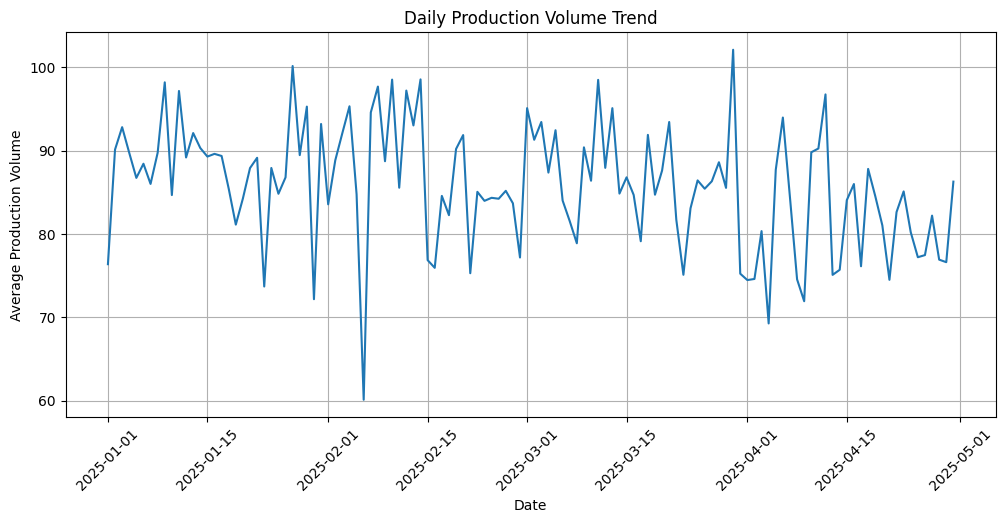

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_production["Date"],
    daily_production["Production_Volume"]
)

plt.xlabel("Date")
plt.ylabel("Average Production Volume")
plt.title("Daily Production Volume Trend")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
mid_date = daily_production["Date"].median()

early_production = daily_production[
    daily_production["Date"] <= mid_date
]["Production_Volume"].mean()

late_production = daily_production[
    daily_production["Date"] > mid_date
]["Production_Volume"].mean()

print("Early-period average production:", round(early_production, 2))
print("Late-period average production:", round(late_production, 2))

Early-period average production: 87.42
Late-period average production: 84.13


In [ ]:
percentage_change = (
    (late_production - early_production)
    / early_production
) * 100

print("Production change:", round(percentage_change, 2), "%")

Production change: -3.77 %


In [ ]:
daily_production["7_Day_Avg"] = (
    daily_production["Production_Volume"]
    .rolling(window=7)
    .mean()
)

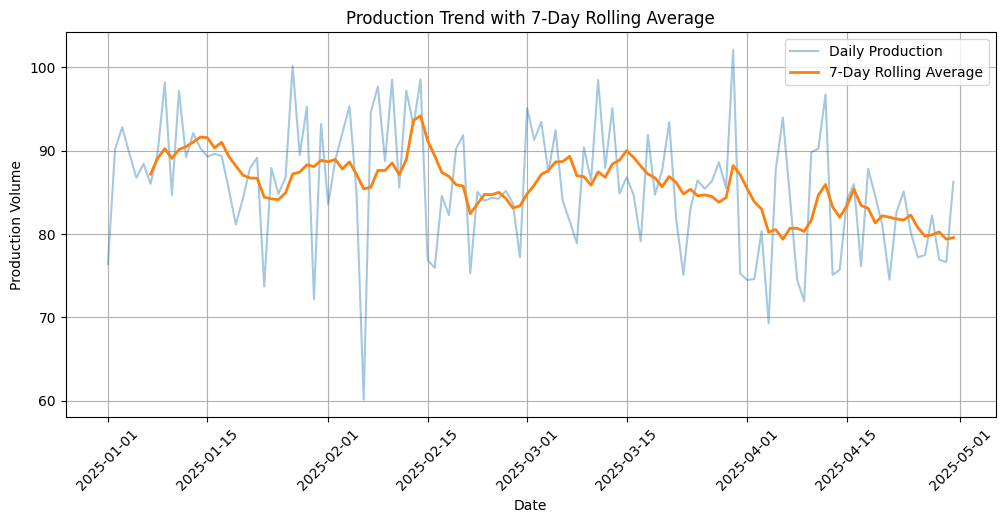

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_production["Date"],
    daily_production["Production_Volume"],
    alpha=0.4,
    label="Daily Production"
)

plt.plot(
    daily_production["Date"],
    daily_production["7_Day_Avg"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.xlabel("Date")
plt.ylabel("Production Volume")
plt.title("Production Trend with 7-Day Rolling Average")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
machine_analysis = df.groupby("Machine_ID").agg(
    Average_Output=("Machine_Output", "mean"),
    Average_Production=("Production_Volume", "mean"),
    Average_Downtime=("Downtime", "mean")
).reset_index()

machine_analysis

,Machine_ID,Average_Output,Average_Production,Average_Downtime
0,M01,100.441343,95.393955,9.846045
1,M02,96.829829,91.063248,9.447521
2,M03,91.955349,86.938062,9.280078
3,M04,98.817442,93.523721,9.775891
4,M05,73.640226,63.970301,17.324211
5,M06,95.415982,90.141161,9.032054
6,M07,100.025392,94.616569,9.133824
7,M08,74.162909,65.329545,16.150727
8,M09,94.225545,89.094059,9.388020
9,M10,98.129248,92.505338,9.347594


In [ ]:
machine_analysis.sort_values(
    "Average_Production",
    ascending=True
)

,Machine_ID,Average_Output,Average_Production,Average_Downtime
4,M05,73.640226,63.970301,17.324211
7,M08,74.162909,65.329545,16.150727
2,M03,91.955349,86.938062,9.280078
8,M09,94.225545,89.094059,9.388020
5,M06,95.415982,90.141161,9.032054
1,M02,96.829829,91.063248,9.447521
9,M10,98.129248,92.505338,9.347594
3,M04,98.817442,93.523721,9.775891
6,M07,100.025392,94.616569,9.133824
0,M01,100.441343,95.393955,9.846045


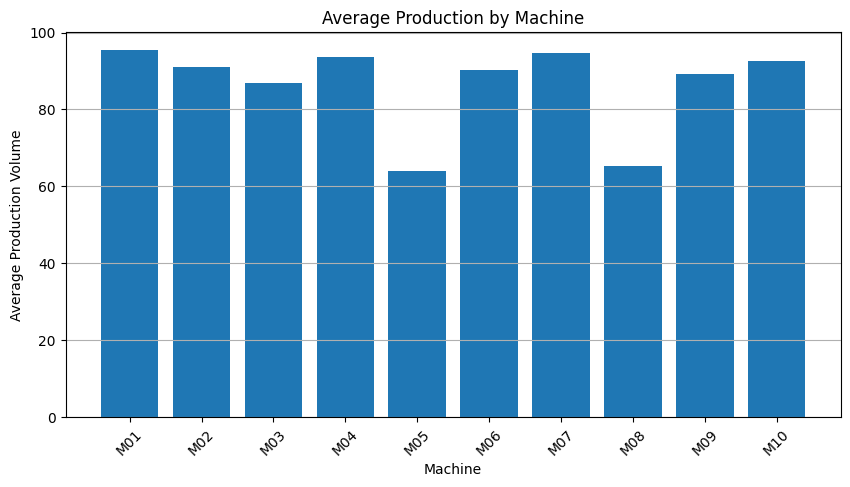

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    machine_analysis["Machine_ID"],
    machine_analysis["Average_Production"]
)

plt.xlabel("Machine")
plt.ylabel("Average Production Volume")
plt.title("Average Production by Machine")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
machine_downtime = df.groupby("Machine_ID")["Downtime"].mean().sort_values(
    ascending=False
)

machine_downtime

,Downtime
Machine_ID,
M05,17.324211
M08,16.150727
M01,9.846045
M04,9.775891
M02,9.447521
M09,9.388020
M10,9.347594
M03,9.280078
M07,9.133824


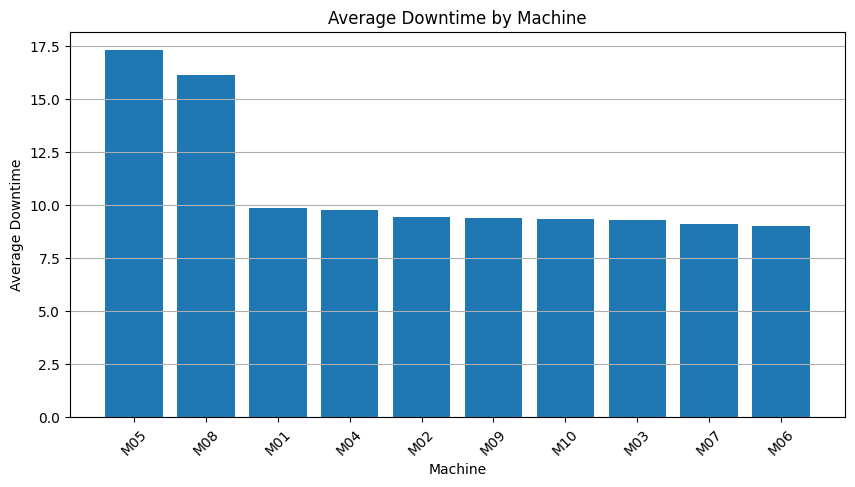

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    machine_downtime.index,
    machine_downtime.values
)

plt.xlabel("Machine")
plt.ylabel("Average Downtime")
plt.title("Average Downtime by Machine")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [ ]:
machine_analysis.sort_values(
    "Average_Downtime",
    ascending=False
)

,Machine_ID,Average_Output,Average_Production,Average_Downtime
4,M05,73.640226,63.970301,17.324211
7,M08,74.162909,65.329545,16.150727
0,M01,100.441343,95.393955,9.846045
3,M04,98.817442,93.523721,9.775891
1,M02,96.829829,91.063248,9.447521
8,M09,94.225545,89.094059,9.388020
9,M10,98.129248,92.505338,9.347594
2,M03,91.955349,86.938062,9.280078
6,M07,100.025392,94.616569,9.133824
5,M06,95.415982,90.141161,9.032054


In [ ]:
best_production = machine_analysis["Average_Production"].max()

machine_analysis["Production_Loss_vs_Best"] = (
    best_production - machine_analysis["Average_Production"]
)

machine_analysis.sort_values(
    "Production_Loss_vs_Best",
    ascending=False
)

,Machine_ID,Average_Output,Average_Production,Average_Downtime,Production_Loss_vs_Best
4,M05,73.640226,63.970301,17.324211,31.423654
7,M08,74.162909,65.329545,16.150727,30.064410
2,M03,91.955349,86.938062,9.280078,8.455893
8,M09,94.225545,89.094059,9.388020,6.299896
5,M06,95.415982,90.141161,9.032054,5.252795
1,M02,96.829829,91.063248,9.447521,4.330707
9,M10,98.129248,92.505338,9.347594,2.888617
3,M04,98.817442,93.523721,9.775891,1.870234
6,M07,100.025392,94.616569,9.133824,0.777387
0,M01,100.441343,95.393955,9.846045,0.000000


In [ ]:
df["Downtime"].describe()

,Downtime
count,1200.000000
mean,10.915258
std,6.436754
min,0.270000
25%,5.890000
50%,9.990000
75%,14.692500
max,35.000000


In [ ]:
shift_downtime = df.groupby("Shift").agg(
    Average_Downtime=("Downtime", "mean"),
    Average_Production=("Production_Volume", "mean")
).reset_index()

shift_downtime

,Shift,Average_Downtime,Average_Production
0,Evening,10.151995,88.628029
1,Morning,10.407257,87.107025
2,Night,12.758295,81.502754


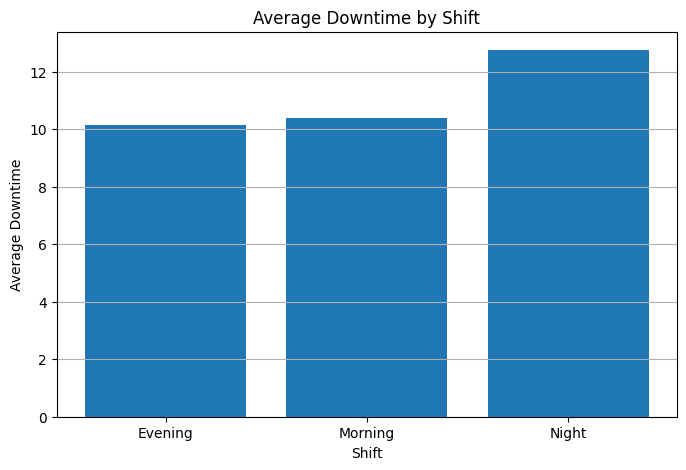

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    shift_downtime["Shift"],
    shift_downtime["Average_Downtime"]
)

plt.xlabel("Shift")
plt.ylabel("Average Downtime")
plt.title("Average Downtime by Shift")
plt.grid(axis="y")

plt.show()

In [ ]:
maintenance_downtime = df.groupby("Maintenance_Status").agg(
    Average_Downtime=("Downtime", "mean"),
    Average_Production=("Production_Volume", "mean")
).reset_index()

maintenance_downtime

,Maintenance_Status,Average_Downtime,Average_Production
0,Due,12.195279,82.894194
1,Good,8.349470,93.354551
2,Overdue,18.169056,65.582278


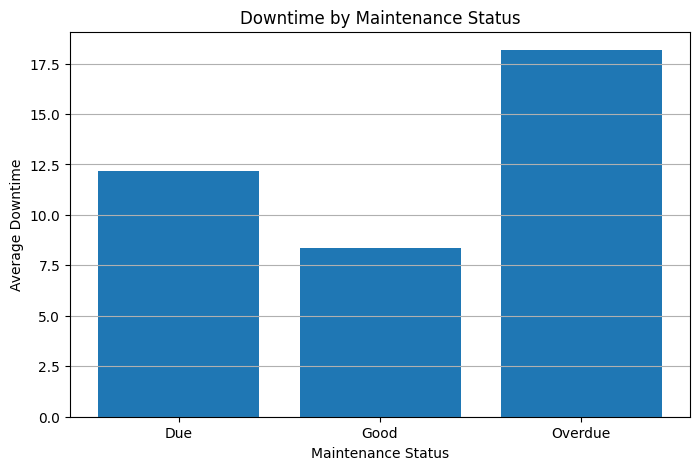

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    maintenance_downtime["Maintenance_Status"],
    maintenance_downtime["Average_Downtime"]
)

plt.xlabel("Maintenance Status")
plt.ylabel("Average Downtime")
plt.title("Downtime by Maintenance Status")
plt.grid(axis="y")

plt.show()

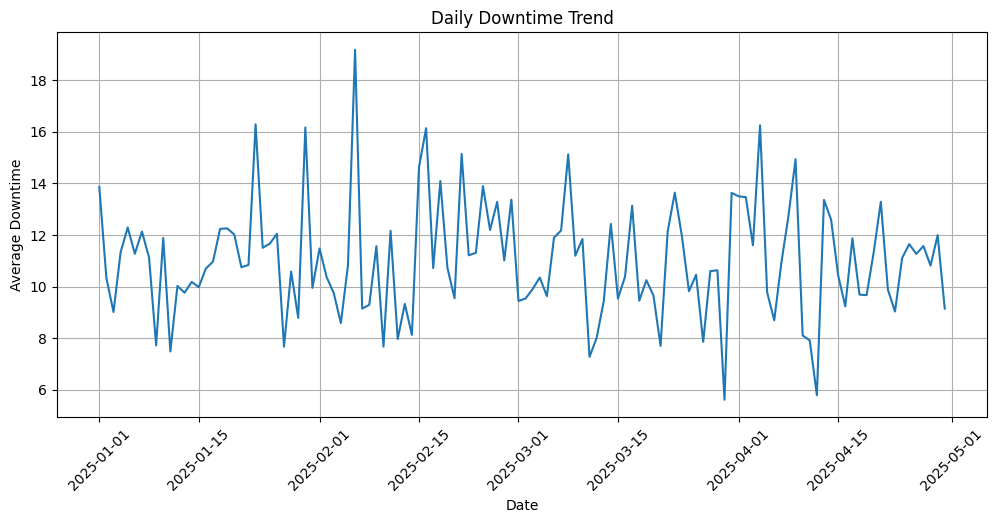

In [ ]:
daily_downtime = df.groupby("Date")["Downtime"].mean().reset_index()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_downtime["Date"],
    daily_downtime["Downtime"]
)

plt.xlabel("Date")
plt.ylabel("Average Downtime")
plt.title("Daily Downtime Trend")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
machine_downtime = (
    df.groupby("Machine_ID")["Downtime"]
    .mean()
    .sort_values(ascending=False)
)

machine_downtime

,Downtime
Machine_ID,
M05,17.324211
M08,16.150727
M01,9.846045
M04,9.775891
M02,9.447521
M09,9.388020
M10,9.347594
M03,9.280078
M07,9.133824


In [ ]:
machine_downtime.head(3)

,Downtime
Machine_ID,
M05,17.324211
M08,16.150727
M01,9.846045


In [ ]:
correlation = df[
    ["Downtime", "Production_Volume"]
].corr()

correlation

,Downtime,Production_Volume
Downtime,1.000000,-0.921332
Production_Volume,-0.921332,1.000000


In [ ]:
print(
    "Downtime vs Production correlation:",
    round(
        df["Downtime"].corr(df["Production_Volume"]),
        3
    )
)

Downtime vs Production correlation: -0.921


In [ ]:
shift_analysis = df.groupby("Shift").agg(
    Average_Production=("Production_Volume", "mean"),
    Average_Output=("Machine_Output", "mean"),
    Average_Downtime=("Downtime", "mean"),
    Record_Count=("Production_Volume", "count")
).reset_index()

shift_analysis

,Shift,Average_Production,Average_Output,Average_Downtime,Record_Count
0,Evening,88.628029,94.355249,10.151995,421
1,Morning,87.107025,93.050781,10.407257,474
2,Night,81.502754,88.450852,12.758295,305


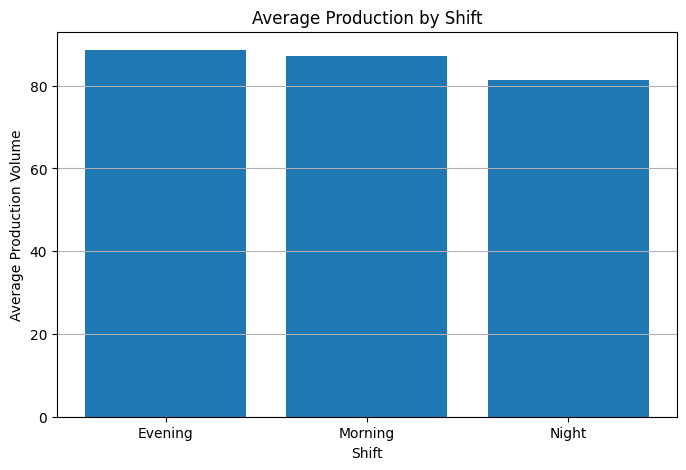

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    shift_analysis["Shift"],
    shift_analysis["Average_Production"]
)

plt.xlabel("Shift")
plt.ylabel("Average Production Volume")
plt.title("Average Production by Shift")
plt.grid(axis="y")

plt.show()

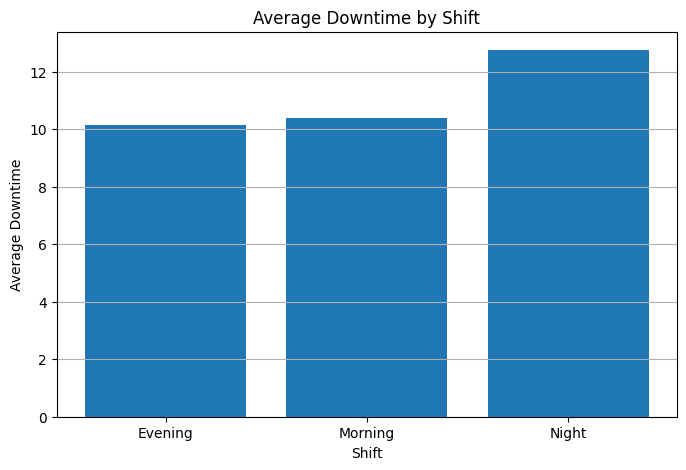

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    shift_analysis["Shift"],
    shift_analysis["Average_Downtime"]
)

plt.xlabel("Shift")
plt.ylabel("Average Downtime")
plt.title("Average Downtime by Shift")
plt.grid(axis="y")

plt.show()

In [ ]:
shift_machine = df.pivot_table(
    index="Machine_ID",
    columns="Shift",
    values="Production_Volume",
    aggfunc="mean"
)

shift_machine

Shift,Evening,Morning,Night
Machine_ID,,,
M01,101.864146,92.539636,92.544211
M02,92.498974,92.490400,86.515000
M03,87.843590,87.300645,84.873929
M04,93.407091,96.273111,89.478621
M05,63.860800,64.295556,63.553448
M06,93.821628,89.577429,86.066765
M07,96.223056,96.297609,87.858500
M08,66.047647,67.424000,62.946098
M09,93.554444,89.942564,81.645385


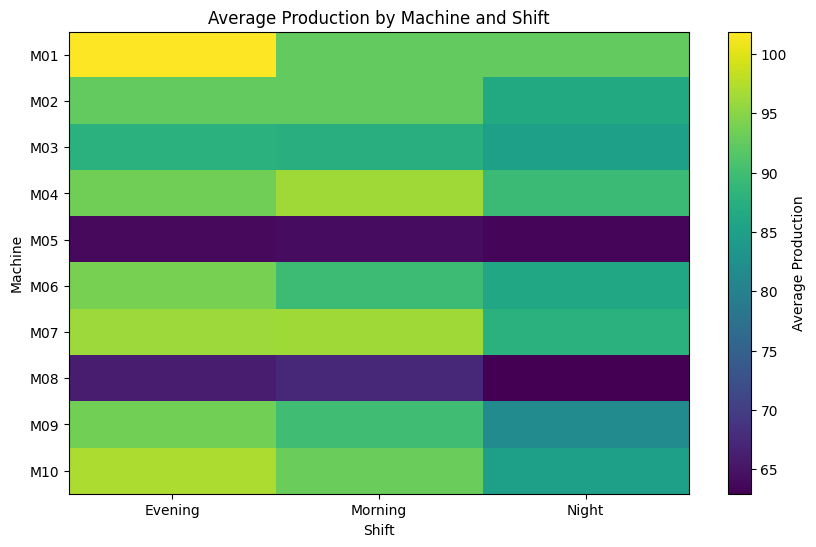

In [ ]:
plt.figure(figsize=(10, 6))

plt.imshow(shift_machine, aspect="auto")

plt.colorbar(label="Average Production")
plt.xticks(
    range(len(shift_machine.columns)),
    shift_machine.columns
)
plt.yticks(
    range(len(shift_machine.index)),
    shift_machine.index
)

plt.xlabel("Shift")
plt.ylabel("Machine")
plt.title("Average Production by Machine and Shift")

plt.show()

In [ ]:
operator_analysis = df.groupby("Operator").agg(
    Average_Production=("Production_Volume", "mean"),
    Average_Output=("Machine_Output", "mean"),
    Average_Downtime=("Downtime", "mean"),
    Records=("Production_Volume", "count")
).reset_index()

operator_analysis

,Operator,Average_Production,Average_Output,Average_Downtime,Records
0,OP01,86.440800,92.684000,10.838900,100
1,OP02,87.917662,93.762857,10.893247,77
2,OP03,88.009241,94.242152,9.960633,79
3,OP04,86.009351,91.545195,10.622078,77
4,OP05,88.596582,94.198481,10.048987,79
5,OP06,83.949359,90.767179,11.851538,78
6,OP07,85.006932,91.353295,11.149886,88
7,OP08,83.650274,90.081644,11.596712,73
8,OP09,86.889605,92.745132,11.023816,76
9,OP10,88.104051,94.176835,10.193418,79


In [ ]:
operator_analysis.sort_values(
    "Average_Production",
    ascending=False
)

,Operator,Average_Production,Average_Output,Average_Downtime,Records
13,OP14,88.961552,94.520862,10.168793,58
4,OP05,88.596582,94.198481,10.048987,79
9,OP10,88.104051,94.176835,10.193418,79
2,OP03,88.009241,94.242152,9.960633,79
1,OP02,87.917662,93.762857,10.893247,77
8,OP09,86.889605,92.745132,11.023816,76
0,OP01,86.440800,92.684000,10.838900,100
12,OP13,86.309524,92.116190,11.033452,84
3,OP04,86.009351,91.545195,10.622078,77
11,OP12,85.316588,91.730471,10.518824,85


In [ ]:
operator_analysis.sort_values(
    "Average_Production",
    ascending=True
)

,Operator,Average_Production,Average_Output,Average_Downtime,Records
7,OP08,83.650274,90.081644,11.596712,73
10,OP11,83.900000,90.357024,12.121071,84
5,OP06,83.949359,90.767179,11.851538,78
6,OP07,85.006932,91.353295,11.149886,88
14,OP15,85.095301,91.477952,11.480120,83
11,OP12,85.316588,91.730471,10.518824,85
3,OP04,86.009351,91.545195,10.622078,77
12,OP13,86.309524,92.116190,11.033452,84
0,OP01,86.440800,92.684000,10.838900,100
8,OP09,86.889605,92.745132,11.023816,76


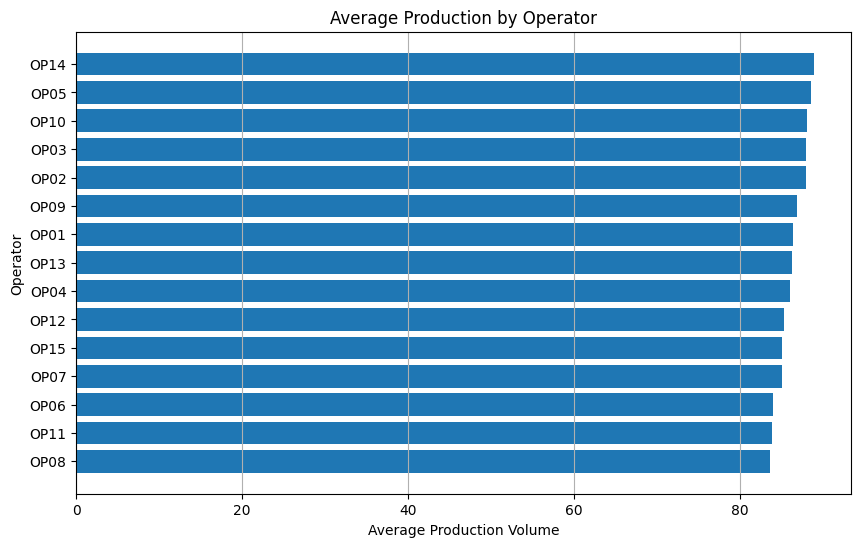

In [ ]:
operator_sorted = operator_analysis.sort_values(
    "Average_Production"
)

plt.figure(figsize=(10, 6))

plt.barh(
    operator_sorted["Operator"],
    operator_sorted["Average_Production"]
)

plt.xlabel("Average Production Volume")
plt.ylabel("Operator")
plt.title("Average Production by Operator")
plt.grid(axis="x")

plt.show()

In [ ]:
operator_analysis.sort_values(
    "Average_Downtime",
    ascending=False
)

,Operator,Average_Production,Average_Output,Average_Downtime,Records
10,OP11,83.900000,90.357024,12.121071,84
5,OP06,83.949359,90.767179,11.851538,78
7,OP08,83.650274,90.081644,11.596712,73
14,OP15,85.095301,91.477952,11.480120,83
6,OP07,85.006932,91.353295,11.149886,88
12,OP13,86.309524,92.116190,11.033452,84
8,OP09,86.889605,92.745132,11.023816,76
1,OP02,87.917662,93.762857,10.893247,77
0,OP01,86.440800,92.684000,10.838900,100
3,OP04,86.009351,91.545195,10.622078,77


In [ ]:
operator_shift = pd.crosstab(
    df["Operator"],
    df["Shift"]
)

operator_shift

Shift,Evening,Morning,Night
Operator,,,
OP01,35,44,21
OP02,25,22,30
OP03,31,31,17
OP04,27,35,15
OP05,30,33,16
OP06,28,30,20
OP07,32,30,26
OP08,33,25,15
OP09,27,27,22


In [ ]:
operator_machine = pd.crosstab(
    df["Operator"],
    df["Machine_ID"]
)

operator_machine

Machine_ID,M01,M02,M03,M04,M05,M06,M07,M08,M09,M10
Operator,,,,,,,,,,
OP01,12,12,9,10,14,10,5,9,10,9
OP02,10,3,8,6,6,5,7,5,12,15
OP03,11,6,10,10,11,7,5,4,6,9
OP04,7,9,6,7,12,2,9,7,6,12
OP05,7,10,6,14,7,11,7,6,9,2
OP06,9,5,2,14,8,6,12,10,4,8
OP07,14,10,10,9,4,12,7,11,3,8
OP08,6,7,12,5,9,5,6,8,7,8
OP09,9,7,8,10,10,8,4,5,7,8


In [ ]:
operator_analysis.sort_values(
    "Average_Production",
    ascending=False
).head(10)

,Operator,Average_Production,Average_Output,Average_Downtime,Records
13,OP14,88.961552,94.520862,10.168793,58
4,OP05,88.596582,94.198481,10.048987,79
9,OP10,88.104051,94.176835,10.193418,79
2,OP03,88.009241,94.242152,9.960633,79
1,OP02,87.917662,93.762857,10.893247,77
8,OP09,86.889605,92.745132,11.023816,76
0,OP01,86.440800,92.684000,10.838900,100
12,OP13,86.309524,92.116190,11.033452,84
3,OP04,86.009351,91.545195,10.622078,77
11,OP12,85.316588,91.730471,10.518824,85


In [ ]:
df["Temperature"].describe()

,Temperature
count,1200.000000
mean,28.904683
std,3.936052
min,20.000000
25%,26.267500
50%,28.830000
75%,31.580000
max,40.000000


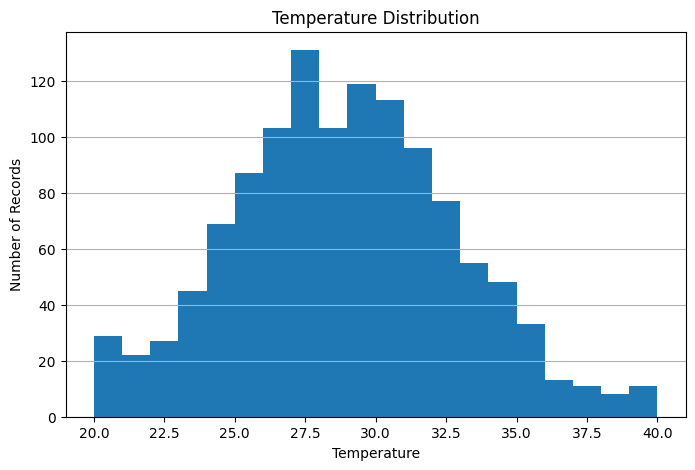

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Temperature"],
    bins=20
)

plt.xlabel("Temperature")
plt.ylabel("Number of Records")
plt.title("Temperature Distribution")
plt.grid(axis="y")

plt.show()

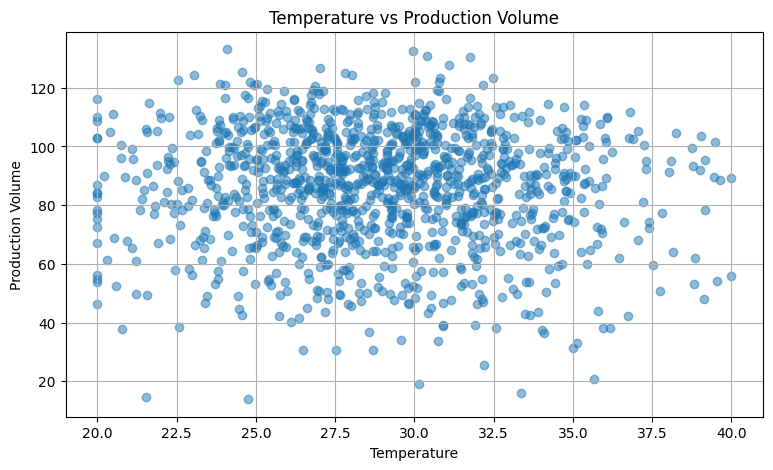

In [ ]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["Temperature"],
    df["Production_Volume"],
    alpha=0.5
)

plt.xlabel("Temperature")
plt.ylabel("Production Volume")
plt.title("Temperature vs Production Volume")
plt.grid(True)

plt.show()

In [ ]:
temperature_corr = df["Temperature"].corr(
    df["Production_Volume"]
)

print(
    "Temperature vs Production correlation:",
    round(temperature_corr, 3)
)

Temperature vs Production correlation: -0.048


In [ ]:
output_corr = df["Temperature"].corr(
    df["Machine_Output"]
)

print(
    "Temperature vs Machine Output correlation:",
    round(output_corr, 3)
)

Temperature vs Machine Output correlation: -0.061


In [ ]:
df["Temperature_Range"] = pd.cut(
    df["Temperature"],
    bins=[0, 25, 30, 35, 100],
    labels=["Low", "Normal", "High", "Very High"]
)

temperature_analysis = df.groupby(
    "Temperature_Range",
    observed=False
).agg(
    Average_Production=("Production_Volume", "mean"),
    Average_Output=("Machine_Output", "mean"),
    Average_Downtime=("Downtime", "mean"),
    Records=("Production_Volume", "count")
).reset_index()

temperature_analysis

,Temperature_Range,Average_Production,Average_Output,Average_Downtime,Records
0,Low,85.830825,92.340670,11.210206,194
1,Normal,87.141238,93.061793,10.753808,541
2,High,85.852931,92.112262,11.007635,389
3,Very High,82.474868,88.354605,10.838816,76


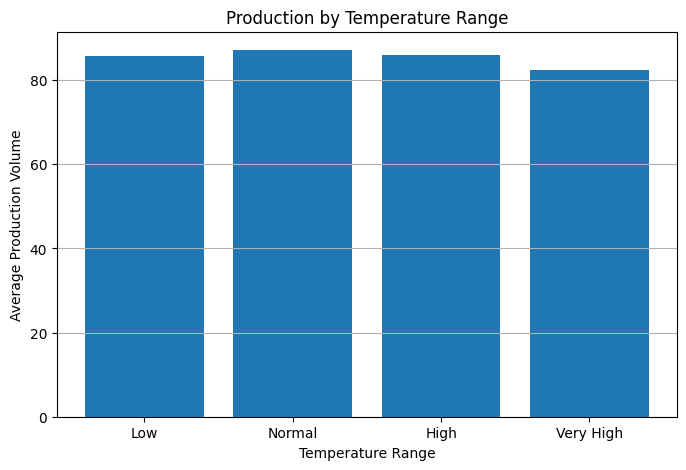

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    temperature_analysis["Temperature_Range"].astype(str),
    temperature_analysis["Average_Production"]
)

plt.xlabel("Temperature Range")
plt.ylabel("Average Production Volume")
plt.title("Production by Temperature Range")
plt.grid(axis="y")

plt.show()

In [ ]:
df["Maintenance_Status"].value_counts()

,count
Maintenance_Status,
Good,679
Due,341
Overdue,180


In [ ]:
maintenance_counts = df["Maintenance_Status"].value_counts()

maintenance_percentage = (
    maintenance_counts / len(df) * 100
).round(2)

maintenance_percentage

,count
Maintenance_Status,
Good,56.58
Due,28.42
Overdue,15.00


In [ ]:
maintenance_analysis = df.groupby("Maintenance_Status").agg(
    Average_Downtime=("Downtime", "mean"),
    Average_Production=("Production_Volume", "mean"),
    Average_Output=("Machine_Output", "mean"),
    Records=("Production_Volume", "count")
).reset_index()

maintenance_analysis

,Maintenance_Status,Average_Downtime,Average_Production,Average_Output,Records
0,Due,12.195279,82.894194,89.840880,341
1,Good,8.349470,93.354551,98.060206,679
2,Overdue,18.169056,65.582278,75.491778,180


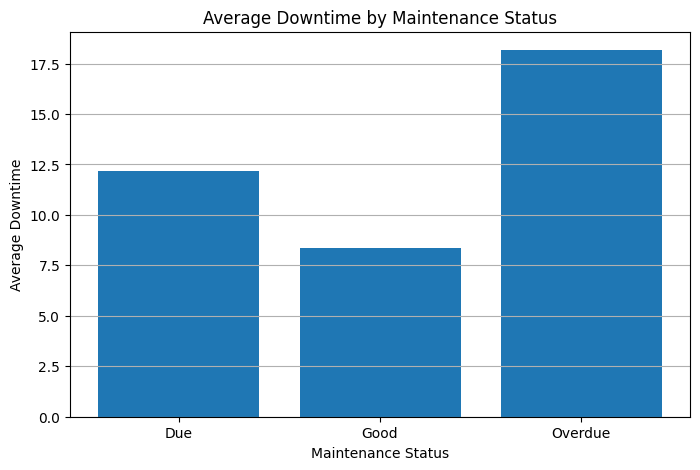

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    maintenance_analysis["Maintenance_Status"],
    maintenance_analysis["Average_Downtime"]
)

plt.xlabel("Maintenance Status")
plt.ylabel("Average Downtime")
plt.title("Average Downtime by Maintenance Status")
plt.grid(axis="y")

plt.show()

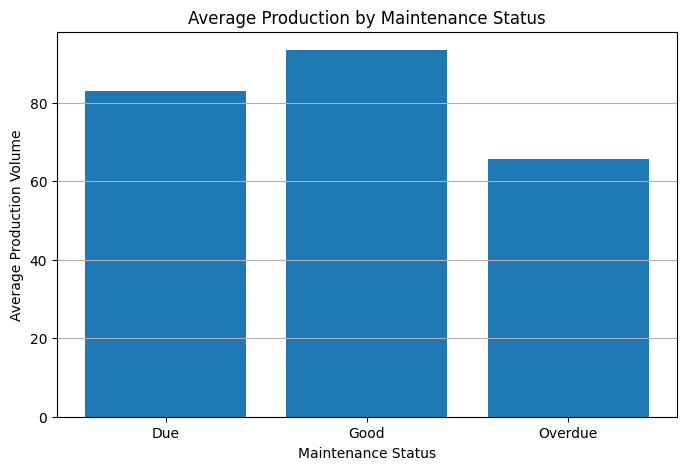

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    maintenance_analysis["Maintenance_Status"],
    maintenance_analysis["Average_Production"]
)

plt.xlabel("Maintenance Status")
plt.ylabel("Average Production Volume")
plt.title("Average Production by Maintenance Status")
plt.grid(axis="y")

plt.show()

In [ ]:
maintenance_machine = pd.crosstab(
    df["Machine_ID"],
    df["Maintenance_Status"]
)

maintenance_machine

Maintenance_Status,Due,Good,Overdue
Machine_ID,,,
M01,28,89,17
M02,35,71,11
M03,38,75,16
M04,37,81,11
M05,40,49,44
M06,31,64,17
M07,25,67,10
M08,36,42,32
M09,27,63,11


In [ ]:
maintenance_machine_pct = pd.crosstab(
    df["Machine_ID"],
    df["Maintenance_Status"],
    normalize="index"
) * 100

maintenance_machine_pct.round(2)

Maintenance_Status,Due,Good,Overdue
Machine_ID,,,
M01,20.90,66.42,12.69
M02,29.91,60.68,9.40
M03,29.46,58.14,12.40
M04,28.68,62.79,8.53
M05,30.08,36.84,33.08
M06,27.68,57.14,15.18
M07,24.51,65.69,9.80
M08,32.73,38.18,29.09
M09,26.73,62.38,10.89


In [ ]:
overdue_percentage = (
    df.groupby("Machine_ID")["Maintenance_Status"]
    .apply(lambda x: (x == "Overdue").mean() * 100)
    .sort_values(ascending=False)
)

overdue_percentage

,Maintenance_Status
Machine_ID,
M05,33.082707
M08,29.090909
M06,15.178571
M01,12.686567
M03,12.403101
M09,10.891089
M07,9.803922
M02,9.401709
M04,8.527132


In [ ]:
overdue_percentage.head(5)

,Maintenance_Status
Machine_ID,
M05,33.082707
M08,29.090909
M06,15.178571
M01,12.686567
M03,12.403101


In [ ]:
good_downtime = df[
    df["Maintenance_Status"] == "Good"
]["Downtime"].mean()

overdue_downtime = df[
    df["Maintenance_Status"] == "Overdue"
]["Downtime"].mean()

difference = overdue_downtime - good_downtime

print("Good maintenance average downtime:",
      round(good_downtime, 2))

print("Overdue maintenance average downtime:",
      round(overdue_downtime, 2))

print("Difference:",
      round(difference, 2))

Good maintenance average downtime: 8.35
Overdue maintenance average downtime: 18.17
Difference: 9.82


In [ ]:
machine_oee = df.groupby("Machine_ID").agg(
    Average_Downtime=("Downtime", "mean"),
    Average_Output=("Machine_Output", "mean"),
    Average_Production=("Production_Volume", "mean")
).reset_index()

machine_oee

,Machine_ID,Average_Downtime,Average_Output,Average_Production
0,M01,9.846045,100.441343,95.393955
1,M02,9.447521,96.829829,91.063248
2,M03,9.280078,91.955349,86.938062
3,M04,9.775891,98.817442,93.523721
4,M05,17.324211,73.640226,63.970301
5,M06,9.032054,95.415982,90.141161
6,M07,9.133824,100.025392,94.616569
7,M08,16.150727,74.162909,65.329545
8,M09,9.388020,94.225545,89.094059
9,M10,9.347594,98.129248,92.505338


In [ ]:
machine_oee["Downtime_Percentage"] = (
    machine_oee["Average_Downtime"] /
    (machine_oee["Average_Downtime"] +
     machine_oee["Average_Production"])
) * 100

machine_oee

,Machine_ID,Average_Downtime,Average_Output,Average_Production,Downtime_Percentage
0,M01,9.846045,100.441343,95.393955,9.355801
1,M02,9.447521,96.829829,91.063248,9.399512
2,M03,9.280078,91.955349,86.938062,9.644832
3,M04,9.775891,98.817442,93.523721,9.463628
4,M05,17.324211,73.640226,63.970301,21.310431
5,M06,9.032054,95.415982,90.141161,9.107352
6,M07,9.133824,100.025392,94.616569,8.803652
7,M08,16.150727,74.162909,65.329545,19.821641
8,M09,9.388020,94.225545,89.094059,9.532719
9,M10,9.347594,98.129248,92.505338,9.177540


In [ ]:
best_production = machine_oee["Average_Production"].max()

machine_oee["Performance_Index"] = (
    machine_oee["Average_Production"] /
    best_production
) * 100

machine_oee

,Machine_ID,Average_Downtime,Average_Output,Average_Production,Downtime_Percentage,Performance_Index
0,M01,9.846045,100.441343,95.393955,9.355801,100.000000
1,M02,9.447521,96.829829,91.063248,9.399512,95.460187
2,M03,9.280078,91.955349,86.938062,9.644832,91.135819
3,M04,9.775891,98.817442,93.523721,9.463628,98.039462
4,M05,17.324211,73.640226,63.970301,21.310431,67.059072
5,M06,9.032054,95.415982,90.141161,9.107352,94.493577
6,M07,9.133824,100.025392,94.616569,8.803652,99.185078
7,M08,16.150727,74.162909,65.329545,19.821641,68.483947
8,M09,9.388020,94.225545,89.094059,9.532719,93.395917
9,M10,9.347594,98.129248,92.505338,9.177540,96.971908


In [ ]:
machine_oee.sort_values(
    ["Average_Downtime", "Performance_Index"],
    ascending=[False, True]
)

,Machine_ID,Average_Downtime,Average_Output,Average_Production,Downtime_Percentage,Performance_Index
4,M05,17.324211,73.640226,63.970301,21.310431,67.059072
7,M08,16.150727,74.162909,65.329545,19.821641,68.483947
0,M01,9.846045,100.441343,95.393955,9.355801,100.000000
3,M04,9.775891,98.817442,93.523721,9.463628,98.039462
1,M02,9.447521,96.829829,91.063248,9.399512,95.460187
8,M09,9.388020,94.225545,89.094059,9.532719,93.395917
9,M10,9.347594,98.129248,92.505338,9.177540,96.971908
2,M03,9.280078,91.955349,86.938062,9.644832,91.135819
6,M07,9.133824,100.025392,94.616569,8.803652,99.185078
5,M06,9.032054,95.415982,90.141161,9.107352,94.493577


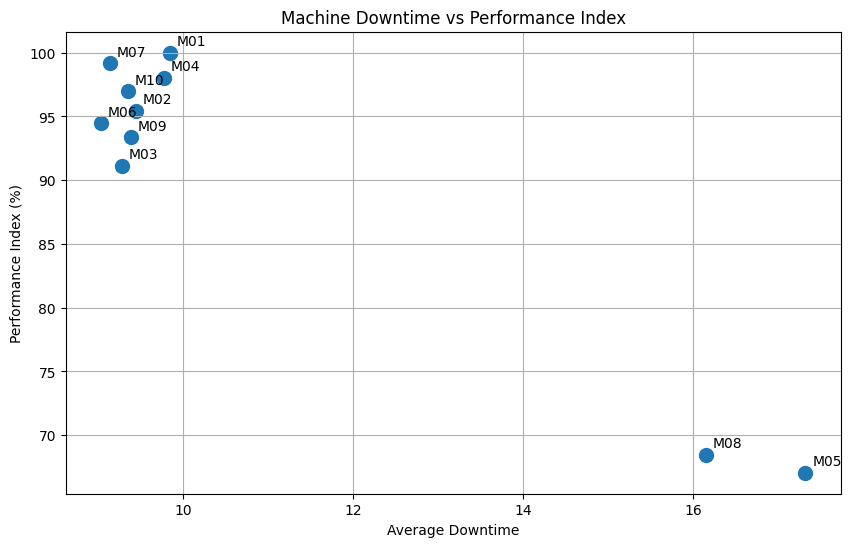

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    machine_oee["Average_Downtime"],
    machine_oee["Performance_Index"],
    s=100
)

for _, row in machine_oee.iterrows():
    plt.annotate(
        row["Machine_ID"],
        (row["Average_Downtime"], row["Performance_Index"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Downtime")
plt.ylabel("Performance Index (%)")
plt.title("Machine Downtime vs Performance Index")
plt.grid(True)

plt.show()

In [ ]:
ml_df = df.copy()

ml_df.head()

,Date,Machine_ID,Machine_Output,Downtime,Shift,Operator,Temperature,Maintenance_Status,Production_Volume,Temperature_Range
0,2025-01-01,M01,73.51,24.09,Morning,OP09,31.81,Overdue,53.17,High
1,2025-01-01,M05,81.21,16.56,Evening,OP13,32.56,Due,77.41,High
2,2025-01-01,M08,79.73,13.98,Morning,OP13,35.75,Due,72.54,Very High
3,2025-01-01,M08,87.41,5.79,Morning,OP07,31.80,Good,85.70,High
4,2025-01-01,M10,82.78,15.43,Night,OP15,25.88,Due,74.50,Normal


In [ ]:
ml_df["Year"] = ml_df["Date"].dt.year
ml_df["Month"] = ml_df["Date"].dt.month
ml_df["Day"] = ml_df["Date"].dt.day
ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek

In [ ]:
ml_df["Days_From_Start"] = (
    ml_df["Date"] - ml_df["Date"].min()
).dt.days

In [ ]:
ml_df[
    [
        "Date",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "Days_From_Start"
    ]
].head()

,Date,Year,Month,Day,DayOfWeek,Days_From_Start
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


In [ ]:
target = "Production_Volume"

In [ ]:
X = ml_df.drop(
    columns=["Production_Volume", "Date"]
)

y = ml_df["Production_Volume"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1200, 13)
y shape: (1200,)


In [ ]:
categorical_columns = [
    "Machine_ID",
    "Shift",
    "Operator",
    "Maintenance_Status"
]

categorical_columns

['Machine_ID', 'Shift', 'Operator', 'Maintenance_Status']

In [ ]:
numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

numerical_columns

['Machine_Output',
 'Downtime',
 'Temperature',
 'Temperature_Range',
 'Year',
 'Month',
 'Day',
 'DayOfWeek',
 'Days_From_Start']

In [ ]:
categorical_columns = [
    "Machine_ID",
    "Shift",
    "Operator",
    "Maintenance_Status"
]

print(categorical_columns)

['Machine_ID', 'Shift', 'Operator', 'Maintenance_Status']


In [ ]:
numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print(numerical_columns)

['Machine_Output', 'Downtime', 'Temperature', 'Temperature_Range', 'Year', 'Month', 'Day', 'DayOfWeek', 'Days_From_Start']


In [ ]:
X.head()

,Machine_ID,Machine_Output,Downtime,Shift,Operator,Temperature,Maintenance_Status,Temperature_Range,Year,Month,Day,DayOfWeek,Days_From_Start
0,M01,73.51,24.09,Morning,OP09,31.81,Overdue,High,2025,1,1,2,0
1,M05,81.21,16.56,Evening,OP13,32.56,Due,High,2025,1,1,2,0
2,M08,79.73,13.98,Morning,OP13,35.75,Due,Very High,2025,1,1,2,0
3,M08,87.41,5.79,Morning,OP07,31.80,Good,High,2025,1,1,2,0
4,M10,82.78,15.43,Night,OP15,25.88,Due,Normal,2025,1,1,2,0


In [ ]:
ml_df = ml_df.sort_values("Date").reset_index(drop=True)

In [ ]:
X = ml_df.drop(columns=["Production_Volume", "Date"])
y = ml_df["Production_Volume"]

In [ ]:
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (960, 13)
Testing data: (240, 13)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (960, 40)
Processed testing shape: (240, 40)


In [ ]:
preprocessor.fit_transform(X_train)

array([[1.0, 0.0, 0.0, ..., 1, 2, 0],
       [0.0, 0.0, 0.0, ..., 1, 2, 0],
       [0.0, 0.0, 0.0, ..., 1, 2, 0],
       ...,
       [0.0, 0.0, 1.0, ..., 6, 6, 95],
       [0.0, 0.0, 0.0, ..., 6, 6, 95],
       [0.0, 1.0, 0.0, ..., 6, 6, 95]], dtype=object)

In [ ]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (960, 40)
Processed testing shape: (240, 40)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
ml_df = ml_df.drop(
    columns=["Temperature_Range"],
    errors="ignore"
)

In [ ]:
X = ml_df.drop(
    columns=["Production_Volume", "Date"]
)

y = ml_df["Production_Volume"]

In [ ]:
categorical_columns = [
    "Machine_ID",
    "Shift",
    "Operator",
    "Maintenance_Status"
]

print(categorical_columns)

['Machine_ID', 'Shift', 'Operator', 'Maintenance_Status']


In [ ]:
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (960, 12)
Testing: (240, 12)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (960, 39)
Processed testing shape: (240, 39)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = rf_model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
comparison = pd.DataFrame({
    "Actual_Production": y_test.values,
    "Predicted_Production": y_pred
})

comparison.head(10)

,Actual_Production,Predicted_Production
0,104.87,106.78750
1,104.91,101.89985
2,102.79,106.65770
3,104.87,104.99015
4,92.49,91.66625
5,82.61,79.42100
6,76.70,80.42260
7,89.47,93.93930
8,57.97,63.08005
9,119.00,115.97495


In [ ]:
comparison["Error"] = (
    comparison["Actual_Production"]
    - comparison["Predicted_Production"]
)

comparison.head(10)

,Actual_Production,Predicted_Production,Error
0,104.87,106.78750,-1.91750
1,104.91,101.89985,3.01015
2,102.79,106.65770,-3.86770
3,104.87,104.99015,-0.12015
4,92.49,91.66625,0.82375
5,82.61,79.42100,3.18900
6,76.70,80.42260,-3.72260
7,89.47,93.93930,-4.46930
8,57.97,63.08005,-5.11005
9,119.00,115.97495,3.02505


In [ ]:
comparison["Absolute_Error"] = comparison["Error"].abs()

comparison.head(10)

,Actual_Production,Predicted_Production,Error,Absolute_Error
0,104.87,106.78750,-1.91750,1.91750
1,104.91,101.89985,3.01015,3.01015
2,102.79,106.65770,-3.86770,3.86770
3,104.87,104.99015,-0.12015,0.12015
4,92.49,91.66625,0.82375,0.82375
5,82.61,79.42100,3.18900,3.18900
6,76.70,80.42260,-3.72260,3.72260
7,89.47,93.93930,-4.46930,4.46930
8,57.97,63.08005,-5.11005,5.11005
9,119.00,115.97495,3.02505,3.02505


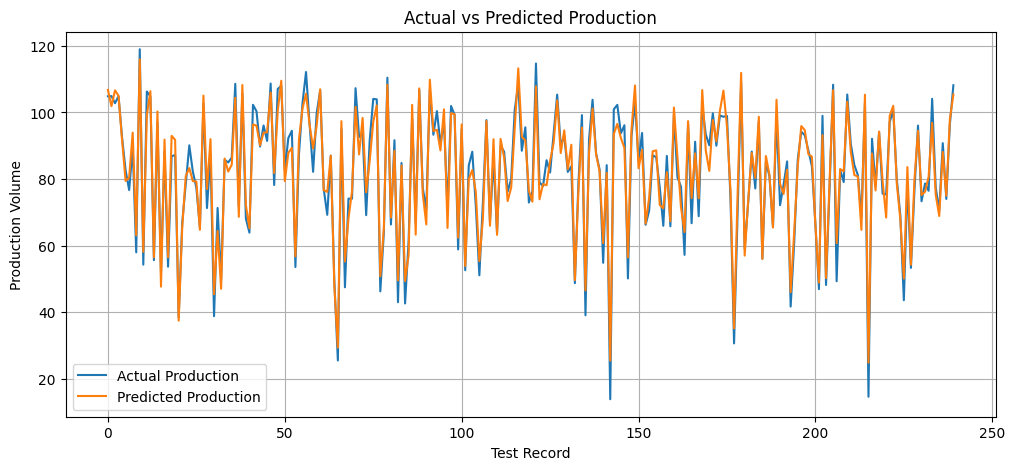

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison["Actual_Production"].values,
    label="Actual Production"
)

plt.plot(
    comparison["Predicted_Production"].values,
    label="Predicted Production"
)

plt.xlabel("Test Record")
plt.ylabel("Production Volume")
plt.title("Actual vs Predicted Production")
plt.legend()
plt.grid(True)

plt.show()

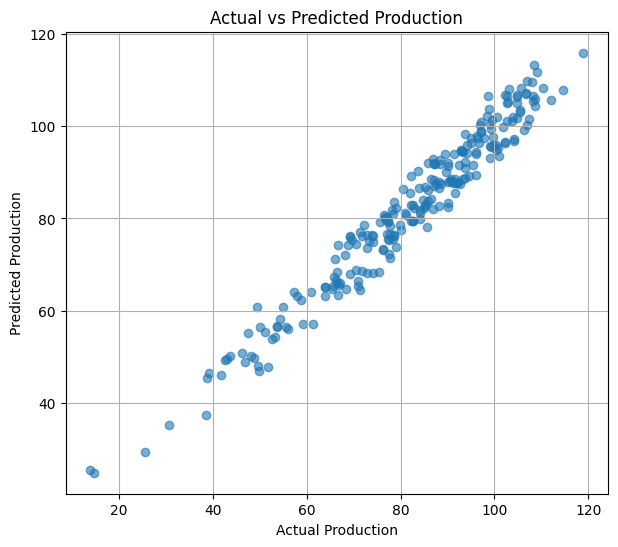

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    comparison["Actual_Production"],
    comparison["Predicted_Production"],
    alpha=0.6
)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production")

plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", round(mae, 2))

MAE: 3.38


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", round(mse, 2))

MSE: 16.35


In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", round(rmse, 2))

RMSE: 4.04


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 3))

R² Score: 0.956


In [ ]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,3.375999
1,MSE,16.353342
2,RMSE,4.043927
3,R²,0.955948


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 39


In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

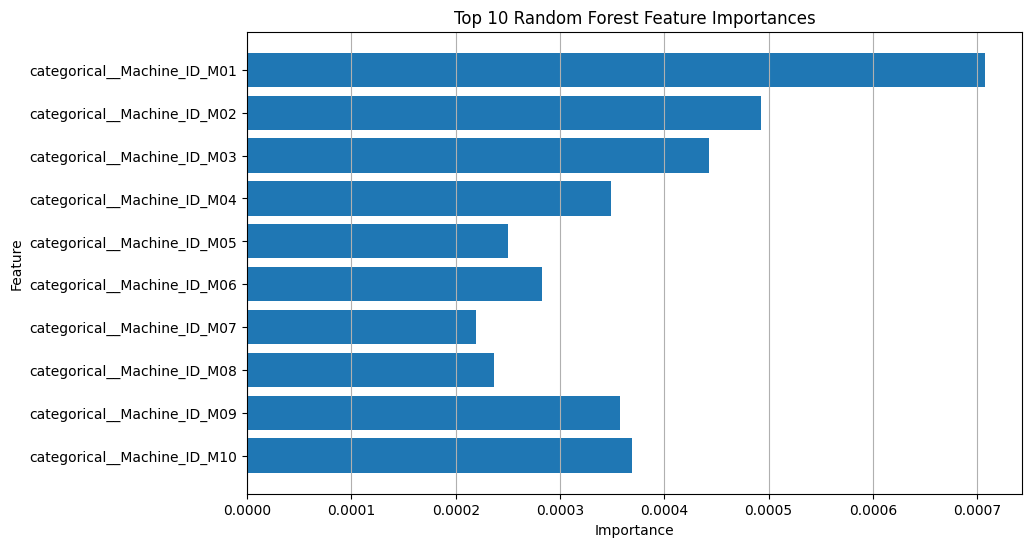

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.grid(axis="x")

plt.show()

In [ ]:
top_5 = feature_importance.head(5)

top_5

,Feature,Importance
0,categorical__Machine_ID_M01,0.000708
1,categorical__Machine_ID_M02,0.000492
2,categorical__Machine_ID_M03,0.000443
3,categorical__Machine_ID_M04,0.000349
4,categorical__Machine_ID_M05,0.000250


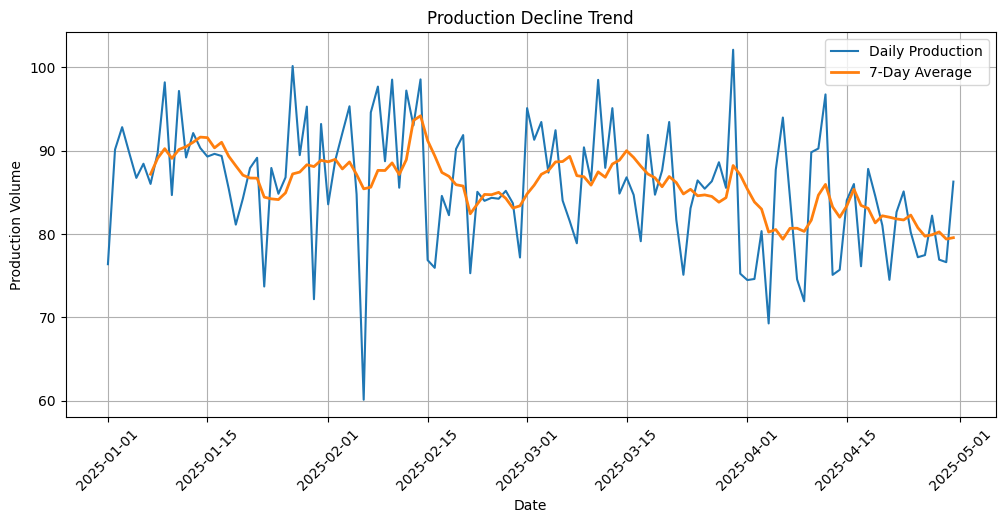

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_production["Date"],
    daily_production["Production_Volume"],
    label="Daily Production"
)

plt.plot(
    daily_production["Date"],
    daily_production["7_Day_Avg"],
    linewidth=2,
    label="7-Day Average"
)

plt.xlabel("Date")
plt.ylabel("Production Volume")
plt.title("Production Decline Trend")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

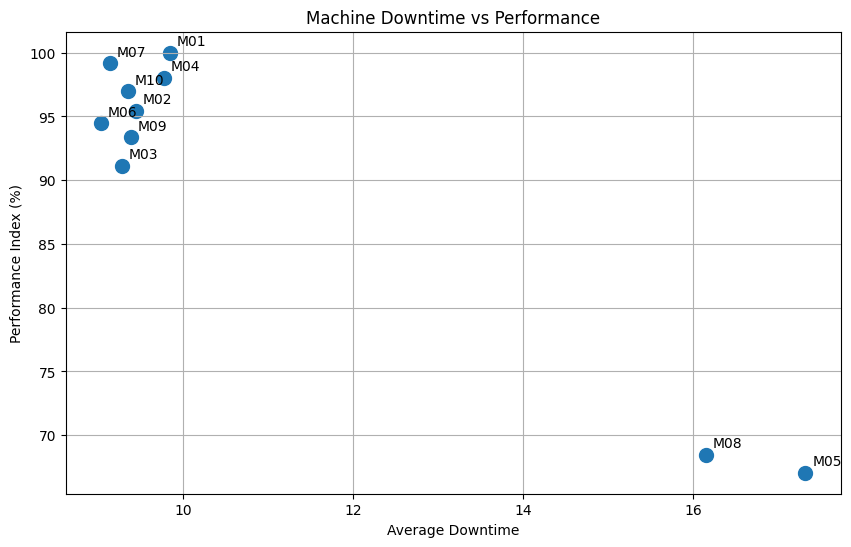

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    machine_oee["Average_Downtime"],
    machine_oee["Performance_Index"],
    s=100
)

for _, row in machine_oee.iterrows():
    plt.annotate(
        row["Machine_ID"],
        (
            row["Average_Downtime"],
            row["Performance_Index"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Downtime")
plt.ylabel("Performance Index (%)")
plt.title("Machine Downtime vs Performance")
plt.grid(True)

plt.show()

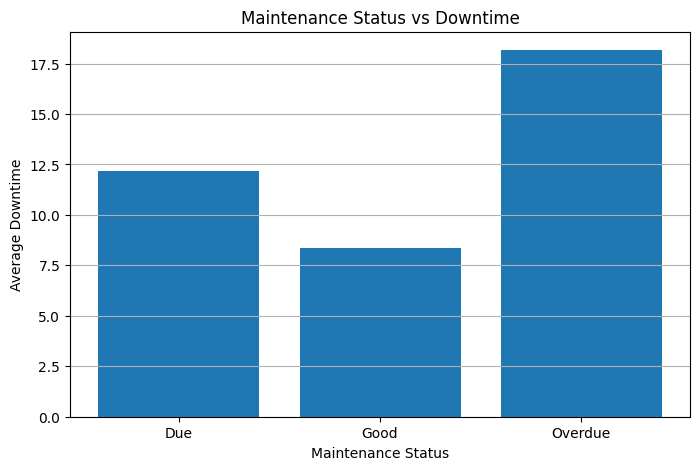

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    maintenance_analysis["Maintenance_Status"],
    maintenance_analysis["Average_Downtime"]
)

plt.xlabel("Maintenance Status")
plt.ylabel("Average Downtime")
plt.title("Maintenance Status vs Downtime")
plt.grid(axis="y")

plt.show()

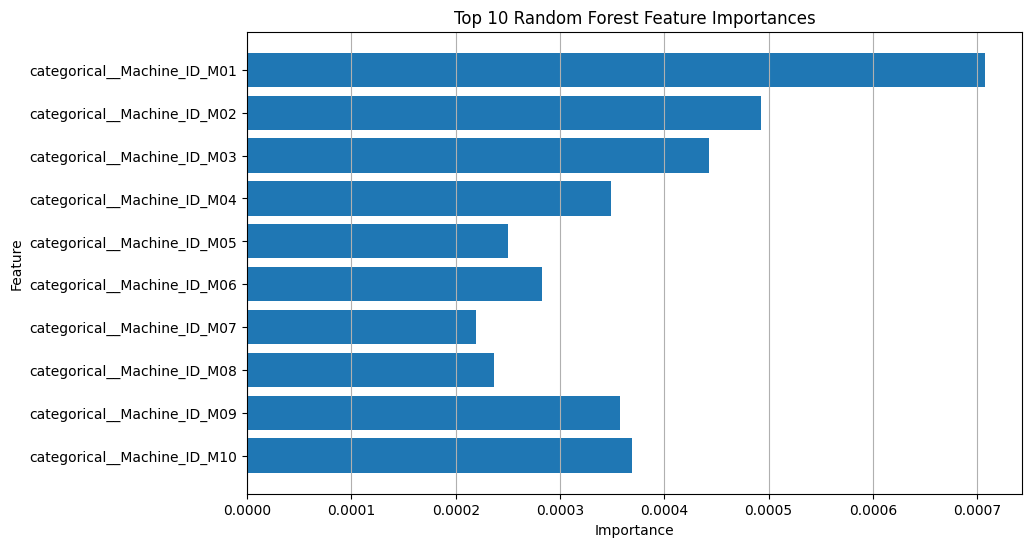

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.grid(axis="x")

plt.show()

In [ ]:
loss_analysis = df.groupby("Machine_ID").agg(
    Average_Production=("Production_Volume", "mean"),
    Average_Output=("Machine_Output", "mean"),
    Average_Downtime=("Downtime", "mean"),
    Records=("Production_Volume", "count")
).reset_index()

loss_analysis

,Machine_ID,Average_Production,Average_Output,Average_Downtime,Records
0,M01,95.393955,100.441343,9.846045,134
1,M02,91.063248,96.829829,9.447521,117
2,M03,86.938062,91.955349,9.280078,129
3,M04,93.523721,98.817442,9.775891,129
4,M05,63.970301,73.640226,17.324211,133
5,M06,90.141161,95.415982,9.032054,112
6,M07,94.616569,100.025392,9.133824,102
7,M08,65.329545,74.162909,16.150727,110
8,M09,89.094059,94.225545,9.388020,101
9,M10,92.505338,98.129248,9.347594,133


In [ ]:
best_production = loss_analysis["Average_Production"].max()

loss_analysis["Production_Loss_vs_Best"] = (
    best_production - loss_analysis["Average_Production"]
)

In [ ]:
loss_analysis = loss_analysis.sort_values(
    "Production_Loss_vs_Best",
    ascending=False
)

loss_analysis

,Machine_ID,Average_Production,Average_Output,Average_Downtime,Records,Production_Loss_vs_Best
4,M05,63.970301,73.640226,17.324211,133,31.423654
7,M08,65.329545,74.162909,16.150727,110,30.064410
2,M03,86.938062,91.955349,9.280078,129,8.455893
8,M09,89.094059,94.225545,9.388020,101,6.299896
5,M06,90.141161,95.415982,9.032054,112,5.252795
1,M02,91.063248,96.829829,9.447521,117,4.330707
9,M10,92.505338,98.129248,9.347594,133,2.888617
3,M04,93.523721,98.817442,9.775891,129,1.870234
6,M07,94.616569,100.025392,9.133824,102,0.777387
0,M01,95.393955,100.441343,9.846045,134,0.000000


In [ ]:
overdue_pct = (
    df.groupby("Machine_ID")["Maintenance_Status"]
    .apply(lambda x: (x == "Overdue").mean() * 100)
    .reset_index(name="Overdue_Maintenance_Percent")
)

loss_analysis = loss_analysis.merge(
    overdue_pct,
    on="Machine_ID",
    how="left"
)

loss_analysis

,Machine_ID,Average_Production,Average_Output,Average_Downtime,Records,Production_Loss_vs_Best,Overdue_Maintenance_Percent
0,M05,63.970301,73.640226,17.324211,133,31.423654,33.082707
1,M08,65.329545,74.162909,16.150727,110,30.064410,29.090909
2,M03,86.938062,91.955349,9.280078,129,8.455893,12.403101
3,M09,89.094059,94.225545,9.388020,101,6.299896,10.891089
4,M06,90.141161,95.415982,9.032054,112,5.252795,15.178571
5,M02,91.063248,96.829829,9.447521,117,4.330707,9.401709
6,M10,92.505338,98.129248,9.347594,133,2.888617,8.270677
7,M04,93.523721,98.817442,9.775891,129,1.870234,8.527132
8,M07,94.616569,100.025392,9.133824,102,0.777387,9.803922
9,M01,95.393955,100.441343,9.846045,134,0.000000,12.686567


In [ ]:
priority_machines = loss_analysis.sort_values(
    "Production_Loss_vs_Best",
    ascending=False
)

priority_machines.head(5)

,Machine_ID,Average_Production,Average_Output,Average_Downtime,Records,Production_Loss_vs_Best,Overdue_Maintenance_Percent
0,M05,63.970301,73.640226,17.324211,133,31.423654,33.082707
1,M08,65.329545,74.162909,16.150727,110,30.064410,29.090909
2,M03,86.938062,91.955349,9.280078,129,8.455893,12.403101
3,M09,89.094059,94.225545,9.388020,101,6.299896,10.891089
4,M06,90.141161,95.415982,9.032054,112,5.252795,15.178571


In [ ]:
priority_machines[
    [
        "Machine_ID",
        "Average_Production",
        "Production_Loss_vs_Best",
        "Average_Downtime",
        "Overdue_Maintenance_Percent"
    ]
].head(5)

,Machine_ID,Average_Production,Production_Loss_vs_Best,Average_Downtime,Overdue_Maintenance_Percent
0,M05,63.970301,31.423654,17.324211,33.082707
1,M08,65.329545,30.064410,16.150727,29.090909
2,M03,86.938062,8.455893,9.280078,12.403101
3,M09,89.094059,6.299896,9.388020,10.891089
4,M06,90.141161,5.252795,9.032054,15.178571


In [ ]:
feature_importance.head(10)

,Feature,Importance
0,categorical__Machine_ID_M01,0.000708
1,categorical__Machine_ID_M02,0.000492
2,categorical__Machine_ID_M03,0.000443
3,categorical__Machine_ID_M04,0.000349
4,categorical__Machine_ID_M05,0.000250
5,categorical__Machine_ID_M06,0.000282
6,categorical__Machine_ID_M07,0.000220
7,categorical__Machine_ID_M08,0.000237
8,categorical__Machine_ID_M09,0.000358
9,categorical__Machine_ID_M10,0.000369


In [ ]:
final_machine_summary = priority_machines[
    [
        "Machine_ID",
        "Average_Production",
        "Average_Downtime",
        "Production_Loss_vs_Best",
        "Overdue_Maintenance_Percent"
    ]
].head(10)

final_machine_summary

,Machine_ID,Average_Production,Average_Downtime,Production_Loss_vs_Best,Overdue_Maintenance_Percent
0,M05,63.970301,17.324211,31.423654,33.082707
1,M08,65.329545,16.150727,30.064410,29.090909
2,M03,86.938062,9.280078,8.455893,12.403101
3,M09,89.094059,9.388020,6.299896,10.891089
4,M06,90.141161,9.032054,5.252795,15.178571
5,M02,91.063248,9.447521,4.330707,9.401709
6,M10,92.505338,9.347594,2.888617,8.270677
7,M04,93.523721,9.775891,1.870234,8.527132
8,M07,94.616569,9.133824,0.777387,9.803922
9,M01,95.393955,9.846045,0.000000,12.686567


In [ ]:
first_period = daily_production.head(
    max(1, len(daily_production) // 4)
)["Production_Volume"].mean()

last_period = daily_production.tail(
    max(1, len(daily_production) // 4)
)["Production_Volume"].mean()

production_change = (
    (last_period - first_period) / first_period
) * 100

print("First-period average:", round(first_period, 2))
print("Last-period average:", round(last_period, 2))
print("Production change:", round(production_change, 2), "%")

First-period average: 87.93
Last-period average: 81.26
Production change: -7.59 %


In [ ]:
highest_downtime_machine = machine_analysis.loc[
    machine_analysis["Average_Downtime"].idxmax()
]

print("Machine:", highest_downtime_machine["Machine_ID"])
print(
    "Average downtime:",
    round(highest_downtime_machine["Average_Downtime"], 2)
)

Machine: M05
Average downtime: 17.32


In [ ]:
largest_loss_machine = loss_analysis.iloc[0]

print("Machine:", largest_loss_machine["Machine_ID"])
print(
    "Production loss vs best:",
    round(
        largest_loss_machine["Production_Loss_vs_Best"],
        2
    )
)

Machine: M05
Production loss vs best: 31.42


In [ ]:
maintenance_analysis

,Maintenance_Status,Average_Downtime,Average_Production,Average_Output,Records
0,Due,12.195279,82.894194,89.840880,341
1,Good,8.349470,93.354551,98.060206,679
2,Overdue,18.169056,65.582278,75.491778,180


In [ ]:
maintenance_highest = maintenance_analysis.loc[
    maintenance_analysis["Average_Downtime"].idxmax()
]

print(
    "Highest downtime maintenance status:",
    maintenance_highest["Maintenance_Status"]
)

print(
    "Average downtime:",
    round(maintenance_highest["Average_Downtime"], 2)
)

Highest downtime maintenance status: Overdue
Average downtime: 18.17


In [ ]:
shift_lowest = shift_analysis.loc[
    shift_analysis["Average_Production"].idxmin()
]

shift_highest_downtime = shift_analysis.loc[
    shift_analysis["Average_Downtime"].idxmax()
]

print("Lowest production shift:",
      shift_lowest["Shift"])

print("Average production:",
      round(shift_lowest["Average_Production"], 2))

print("Highest downtime shift:",
      shift_highest_downtime["Shift"])

print("Average downtime:",
      round(shift_highest_downtime["Average_Downtime"], 2))

Lowest production shift: Night
Average production: 81.5
Highest downtime shift: Night
Average downtime: 12.76


In [ ]:
print(
    "Temperature-Production correlation:",
    round(temperature_corr, 3)
)

Temperature-Production correlation: -0.048


In [ ]:
feature_importance.head(5)

,Feature,Importance
0,categorical__Machine_ID_M01,0.000708
1,categorical__Machine_ID_M02,0.000492
2,categorical__Machine_ID_M03,0.000443
3,categorical__Machine_ID_M04,0.000349
4,categorical__Machine_ID_M05,0.000250


In [ ]:
final_machine_summary

,Machine_ID,Average_Production,Average_Downtime,Production_Loss_vs_Best,Overdue_Maintenance_Percent
0,M05,63.970301,17.324211,31.423654,33.082707
1,M08,65.329545,16.150727,30.064410,29.090909
2,M03,86.938062,9.280078,8.455893,12.403101
3,M09,89.094059,9.388020,6.299896,10.891089
4,M06,90.141161,9.032054,5.252795,15.178571
5,M02,91.063248,9.447521,4.330707,9.401709
6,M10,92.505338,9.347594,2.888617,8.270677
7,M04,93.523721,9.775891,1.870234,8.527132
8,M07,94.616569,9.133824,0.777387,9.803922
9,M01,95.393955,9.846045,0.000000,12.686567


In [ ]:
feature_importance.head(10)

,Feature,Importance
0,categorical__Machine_ID_M01,0.000708
1,categorical__Machine_ID_M02,0.000492
2,categorical__Machine_ID_M03,0.000443
3,categorical__Machine_ID_M04,0.000349
4,categorical__Machine_ID_M05,0.000250
5,categorical__Machine_ID_M06,0.000282
6,categorical__Machine_ID_M07,0.000220
7,categorical__Machine_ID_M08,0.000237
8,categorical__Machine_ID_M09,0.000358
9,categorical__Machine_ID_M10,0.000369


In [ ]:
shift_analysis

,Shift,Average_Production,Average_Output,Average_Downtime,Record_Count
0,Evening,88.628029,94.355249,10.151995,421
1,Morning,87.107025,93.050781,10.407257,474
2,Night,81.502754,88.450852,12.758295,305
